In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('bank-additional-full.csv', sep=';')
print(df.shape)

(41188, 21)


In [2]:
print("Duplikati pre:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape posle:", df.shape)

Duplikati pre: 12
Shape posle: (41176, 21)


In [3]:
df = df[df['duration'] != 0]
print("Shape posle:", df.shape)

Shape posle: (41172, 21)


In [4]:
cols_to_drop = ['default', 'housing', 'loan', 'emp.var.rate', 'nr.employed']
df = df.drop(columns=cols_to_drop)
print(df.columns.tolist())

['age', 'job', 'marital', 'education', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'y']


In [5]:
df['was_contacted_before'] = (df['pdays'] != 999).astype(int)
df['pdays'] = df['pdays'].replace(999, 0)  # 0 = nije bilo kontakta (umesto 999)

In [ ]:
duration_col = df['duration'].copy()  # cuvamo za benchmark analizu
df_model = df.drop(columns=['duration'])  # duration koristimo za realan model zato sto je on poznat tek posle poziva, pa ga nema smisla koristiti

In [7]:
df_model['y'] = df_model['y'].map({'yes': 1, 'no': 0})

In [8]:
print(df_model.shape)
df_model.head()

(41172, 16)


,age,job,marital,education,contact,month,day_of_week,campaign,pdays,previous,poutcome,cons.price.idx,cons.conf.idx,euribor3m,y,was_contacted_before
0,56,housemaid,married,basic.4y,telephone,may,mon,1,0,0,nonexistent,93.994,-36.4,4.857,0,0
1,57,services,married,high.school,telephone,may,mon,1,0,0,nonexistent,93.994,-36.4,4.857,0,0
2,37,services,married,high.school,telephone,may,mon,1,0,0,nonexistent,93.994,-36.4,4.857,0,0
3,40,admin.,married,basic.6y,telephone,may,mon,1,0,0,nonexistent,93.994,-36.4,4.857,0,0
4,56,services,married,high.school,telephone,may,mon,1,0,0,nonexistent,93.994,-36.4,4.857,0,0


In [9]:
print(df_model.shape)

(41172, 16)


In [10]:
df_model = pd.get_dummies(df_model, columns=['job', 'marital', 'contact', 'month', 'day_of_week', 'poutcome'])

In [11]:
education_order = {
    'illiterate': 0,
    'basic.4y': 1,
    'basic.6y': 2,
    'basic.9y': 3,
    'high.school': 4,
    'professional.course': 5,
    'university.degree': 6,
    'unknown': -1  # posebna oznaka za nepoznato
}
df_model['education'] = df_model['education'].map(education_order)

In [12]:
print(df_model.shape)
print(df_model.isnull().sum().sum())  #provera da li ima NaN vrednosti
df_model.head()


(41172, 46)
0


,age,education,campaign,pdays,previous,cons.price.idx,cons.conf.idx,euribor3m,y,was_contacted_before,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
0,56,1,1,0,0,93.994,-36.4,4.857,0,0,...,False,False,False,True,False,False,False,False,True,False
1,57,4,1,0,0,93.994,-36.4,4.857,0,0,...,False,False,False,True,False,False,False,False,True,False
2,37,4,1,0,0,93.994,-36.4,4.857,0,0,...,False,False,False,True,False,False,False,False,True,False
3,40,2,1,0,0,93.994,-36.4,4.857,0,0,...,False,False,False,True,False,False,False,False,True,False
4,56,4,1,0,0,93.994,-36.4,4.857,0,0,...,False,False,False,True,False,False,False,False,True,False


In [13]:
bool_cols = df_model.select_dtypes(include='bool').columns
df_model[bool_cols] = df_model[bool_cols].astype(int)    #pretvara bool promenljive u int zbog modela

In [14]:
from sklearn.preprocessing import StandardScaler

numeric_cols_to_scale = ['age', 'campaign', 'pdays', 'previous', 'cons.price.idx', 'cons.conf.idx', 'euribor3m']

scaler = StandardScaler()
df_model[numeric_cols_to_scale] = scaler.fit_transform(df_model[numeric_cols_to_scale])

df_model.head()

,age,education,campaign,pdays,previous,cons.price.idx,cons.conf.idx,euribor3m,y,was_contacted_before,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
0,1.533224,1,-0.565911,-0.164045,-0.34957,0.722579,0.886562,0.71244,0,0,...,0,0,0,1,0,0,0,0,1,0
1,1.629191,4,-0.565911,-0.164045,-0.34957,0.722579,0.886562,0.71244,0,0,...,0,0,0,1,0,0,0,0,1,0
2,-0.290131,4,-0.565911,-0.164045,-0.34957,0.722579,0.886562,0.71244,0,0,...,0,0,0,1,0,0,0,0,1,0
3,-0.002233,2,-0.565911,-0.164045,-0.34957,0.722579,0.886562,0.71244,0,0,...,0,0,0,1,0,0,0,0,1,0
4,1.533224,4,-0.565911,-0.164045,-0.34957,0.722579,0.886562,0.71244,0,0,...,0,0,0,1,0,0,0,0,1,0


In [15]:
X = df_model.drop(columns=['y'])
y = df_model['y']

print(X.shape, y.shape)   #provera redova i kolona

(41172, 45) (41172,)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train y distribucija:\n", y_train.value_counts(normalize=True))
print("Test y distribucija:\n", y_test.value_counts(normalize=True))

Train: (32937, 45) Test: (8235, 45)
Train y distribucija:
 y
0    0.88733
1    0.11267
Name: proportion, dtype: float64
Test y distribucija:
 y
0    0.88731
1    0.11269
Name: proportion, dtype: float64


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

              precision    recall  f1-score   support

           0       0.95      0.85      0.90      7307
           1       0.35      0.65      0.46       928

    accuracy                           0.83      8235
   macro avg       0.65      0.75      0.68      8235
weighted avg       0.88      0.83      0.85      8235

ROC-AUC: 0.7967601921633957


In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_rf))

              precision    recall  f1-score   support

           0       0.93      0.91      0.92      7307
           1       0.40      0.47      0.43       928

    accuracy                           0.86      8235
   macro avg       0.66      0.69      0.67      8235
weighted avg       0.87      0.86      0.86      8235

ROC-AUC: 0.7766306252153108


In [19]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
y_pred_proba_gb = gb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_gb))

              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7307
           1       0.65      0.21      0.32       928

    accuracy                           0.90      8235
   macro avg       0.78      0.60      0.63      8235
weighted avg       0.88      0.90      0.87      8235

ROC-AUC: 0.8079888704973501


In [20]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight('balanced', y_train)
gb_balanced = GradientBoostingClassifier(random_state=42)
gb_balanced.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_gb2 = gb_balanced.predict(X_test)
y_pred_proba_gb2 = gb_balanced.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_gb2))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_gb2))

              precision    recall  f1-score   support

           0       0.95      0.85      0.90      7307
           1       0.37      0.66      0.47       928

    accuracy                           0.83      8235
   macro avg       0.66      0.76      0.69      8235
weighted avg       0.89      0.83      0.85      8235

ROC-AUC: 0.8120109790800507


In [21]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5],
    'min_samples_leaf': [1, 5]
}

gb_tuning = GradientBoostingClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=gb_tuning,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train, sample_weight=compute_sample_weight('balanced', y_train))

print("Najbolji parametri:", grid_search.best_params_)
print("Najbolji F1 (cross-validation):", grid_search.best_score_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Najbolji parametri: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 100}
Najbolji F1 (cross-validation): 0.7126292336771831


In [22]:
best_gb = grid_search.best_estimator_

y_pred_best = best_gb.predict(X_test)
y_pred_proba_best = best_gb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_best))

              precision    recall  f1-score   support

           0       0.95      0.85      0.90      7307
           1       0.37      0.66      0.47       928

    accuracy                           0.83      8235
   macro avg       0.66      0.76      0.69      8235
weighted avg       0.89      0.83      0.85      8235

ROC-AUC: 0.8120109790800507


In [23]:
import pandas as pd

importances = gb_balanced.feature_importances_
feature_names = X_train.columns

feat_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print(feat_importance_df.head(15))

                 feature  importance
7              euribor3m    0.658584
6          cons.conf.idx    0.136238
33             month_may    0.040967
8   was_contacted_before    0.025771
35             month_oct    0.022550
0                    age    0.017827
2               campaign    0.013481
3                  pdays    0.011729
42      poutcome_failure    0.011311
5         cons.price.idx    0.010615
25      contact_cellular    0.009194
26     contact_telephone    0.008446
32             month_mar    0.006420
44      poutcome_success    0.002531
10       job_blue-collar    0.002167


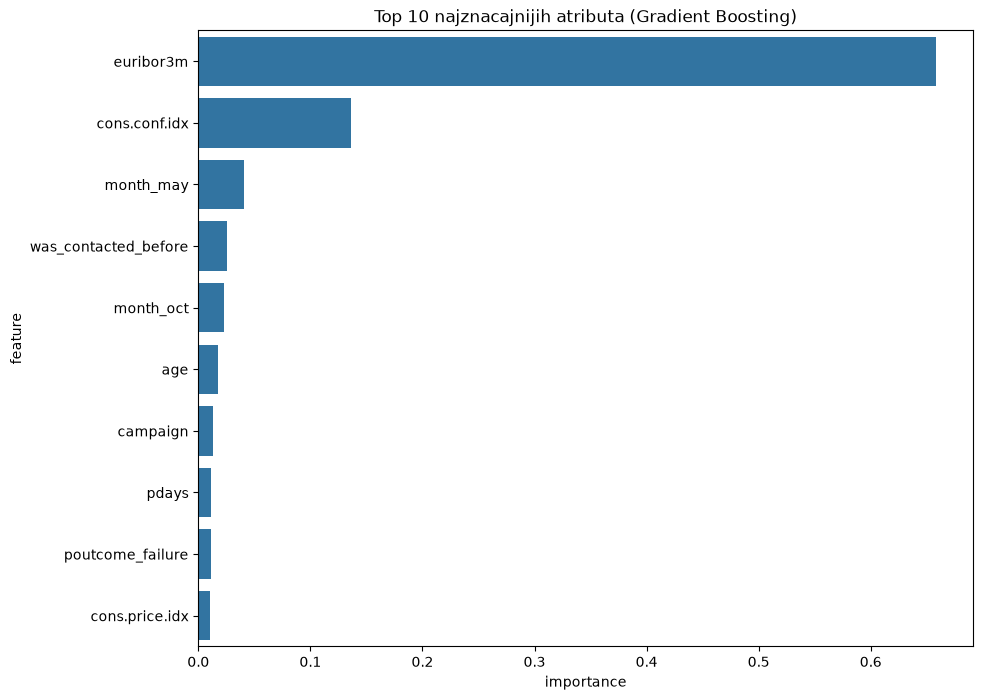

In [24]:
#vizuelni prikaz feature importance-a
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,8))
sns.barplot(x='importance', y='feature', data=feat_importance_df.head(10))
plt.title('Top 10 najznacajnijih atributa (Gradient Boosting)')
plt.show()

In [25]:
top_features = feat_importance_df.head(10)['feature'].tolist()
print(top_features)

X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

gb_top = GradientBoostingClassifier(random_state=42)
gb_top.fit(X_train_top, y_train, sample_weight=compute_sample_weight('balanced', y_train))

y_pred_top = gb_top.predict(X_test_top)
y_pred_proba_top = gb_top.predict_proba(X_test_top)[:, 1]

print(classification_report(y_test, y_pred_top))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_top))

#OVAJ KOD POKAZUJE DA SU VREDNOSTI TOP 10 I SVIH 45 ATRIBUTA GOTOVO ISTE, tkd mozemo samo koristiti top 10 atributa za model

['euribor3m', 'cons.conf.idx', 'month_may', 'was_contacted_before', 'month_oct', 'age', 'campaign', 'pdays', 'poutcome_failure', 'cons.price.idx']
              precision    recall  f1-score   support

           0       0.95      0.85      0.90      7307
           1       0.36      0.67      0.47       928

    accuracy                           0.83      8235
   macro avg       0.66      0.76      0.68      8235
weighted avg       0.89      0.83      0.85      8235

ROC-AUC: 0.8062219948514178


In [26]:
import joblib

joblib.dump(gb_top, 'model_final.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(top_features, 'top_features.pkl')
joblib.dump(education_order, 'education_order.pkl')

#model = joblib.load('model_final.pkl') - ponovno pokretanje modela, sacuvan model

print("Model i potrebni objekti sacuvani.")

Model i potrebni objekti sacuvani.
